# Word2Vec Embedding Visualization

Visual exploration of trained Skip-Gram embeddings (300d, Text8).

- **t-SNE** projection of semantic clusters to 2D
- **Similarity heatmap** with hierarchical clustering

In [8]:
import joblib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.cluster.hierarchy import linkage
from sklearn.manifold import TSNE

from word2vec.model import SkipGramNS

## 1. Load Model & Vocabulary

In [9]:
model = SkipGramNS.load("../data/best_model.npz")
vocab = joblib.load("../data/best_vocab.pkl")

# Normalize embeddings for cosine similarity
norms = np.linalg.norm(model.w_in, axis=1, keepdims=True) + 1e-10
normalized = model.w_in / norms

print(f"Vocabulary: {model.vocab_size:,} words")
print(f"Embedding dim: {model.embedding_dim}")

Vocabulary: 44,611 words
Embedding dim: 300


## 2. Semantic Clusters — t-SNE

Select ~100 words from 6 semantic categories and project to 2D with t-SNE.

In [10]:
CATEGORIES = {
    "Countries": [
        "france", "germany", "italy", "japan", "china", "russia", "spain",
        "brazil", "india", "canada", "australia", "mexico", "sweden", "poland",
        "egypt", "turkey", "greece", "portugal", "ireland", "norway",
    ],
    "Capitals": [
        "paris", "berlin", "rome", "tokyo", "beijing", "moscow", "madrid",
        "delhi", "ottawa", "canberra", "stockholm", "warsaw",
        "cairo", "athens", "lisbon", "dublin", "oslo",
    ],
    "Numbers": [
        "one", "two", "three", "four", "five", "six", "seven", "eight",
        "nine", "ten", "eleven", "twelve", "thirteen", "twenty", "hundred",
    ],
    "Animals": [
        "dog", "cat", "horse", "fish", "bird", "lion", "tiger", "bear",
        "wolf", "eagle", "shark", "whale", "elephant", "monkey", "snake",
        "rabbit", "deer", "fox",
    ],
    "Technology": [
        "computer", "software", "internet", "algorithm", "database",
        "processor", "keyboard", "server", "linux", "windows", "hardware",
        "programming", "network", "digital", "binary", "memory",
    ],
    "Colors": [
        "red", "blue", "green", "yellow", "black", "white", "brown",
        "purple", "orange", "pink", "grey", "golden", "silver",
    ],
}

# Filter to words present in vocabulary
words, labels, vectors = [], [], []
for category, word_list in CATEGORIES.items():
    for w in word_list:
        if w in vocab.word2id:
            words.append(w)
            labels.append(category)
            vectors.append(normalized[vocab.word2id[w]])

vectors = np.array(vectors)
print(f"Selected {len(words)} words from {len(CATEGORIES)} categories")

Selected 99 words from 6 categories


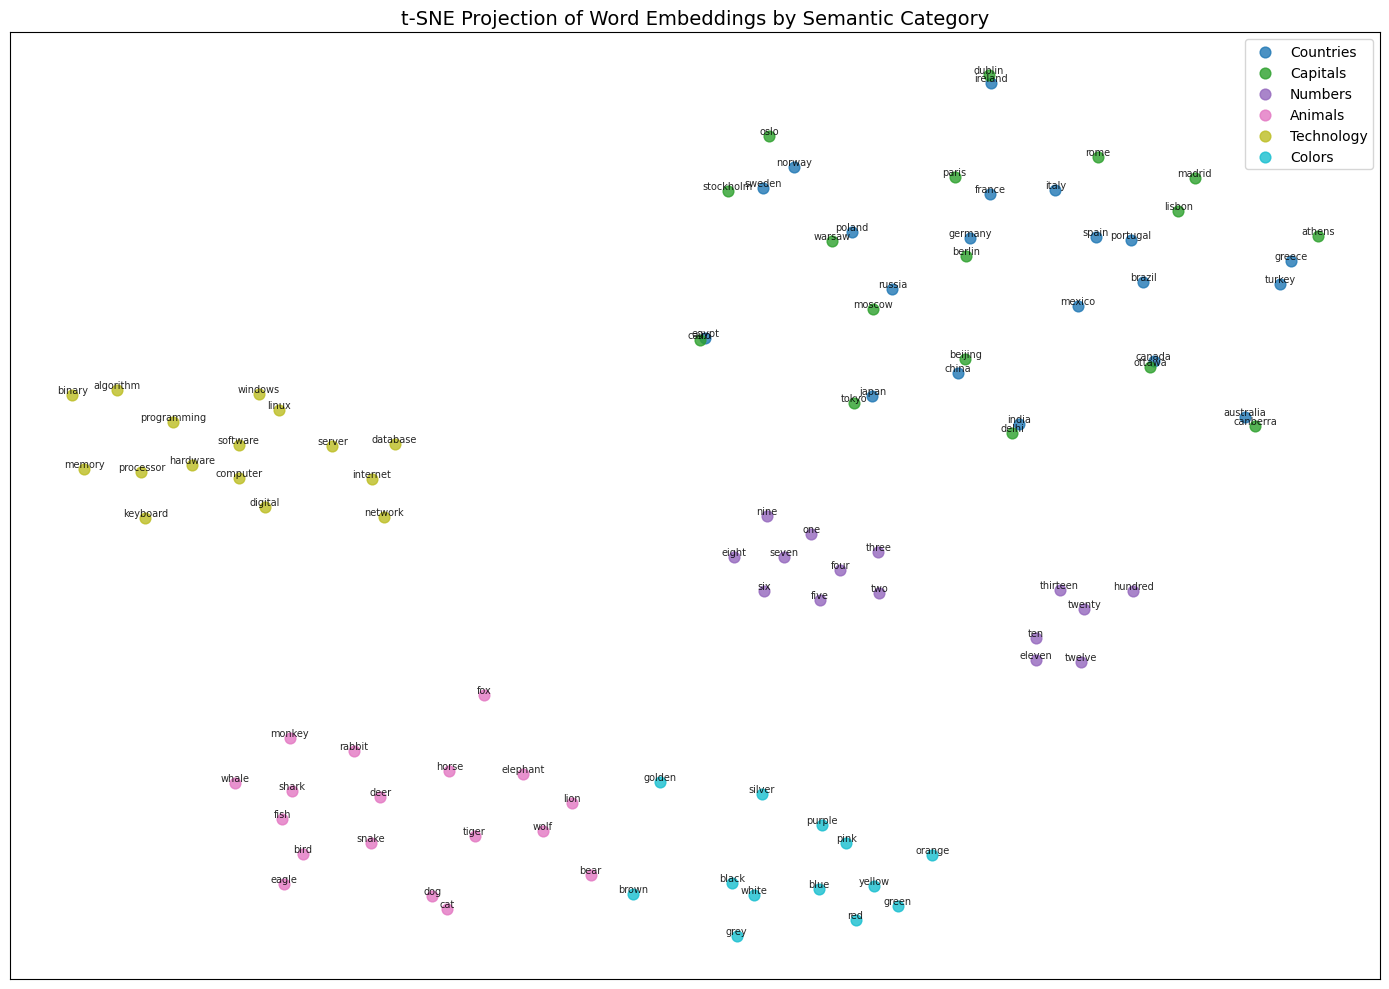

In [11]:
tsne = TSNE(n_components=2, perplexity=20, random_state=42, max_iter=2000)
coords = tsne.fit_transform(vectors)

category_names = list(CATEGORIES.keys())
colors = plt.cm.tab10(np.linspace(0, 1, len(category_names)))
color_map = dict(zip(category_names, colors))

fig, ax = plt.subplots(figsize=(14, 10))
for cat in category_names:
    mask = [l == cat for l in labels]
    idx = np.where(mask)[0]
    ax.scatter(coords[idx, 0], coords[idx, 1], c=[color_map[cat]], label=cat, s=60, alpha=0.8)
    for i in idx:
        ax.annotate(words[i], (coords[i, 0], coords[i, 1]),
                     fontsize=7, alpha=0.85, ha="center", va="bottom")

ax.legend(fontsize=10, loc="best")
ax.set_title("t-SNE Projection of Word Embeddings by Semantic Category", fontsize=14)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()

## 3. Countries & Capitals — Zoom

t-SNE on just countries and capitals to check if capitals cluster near their countries.

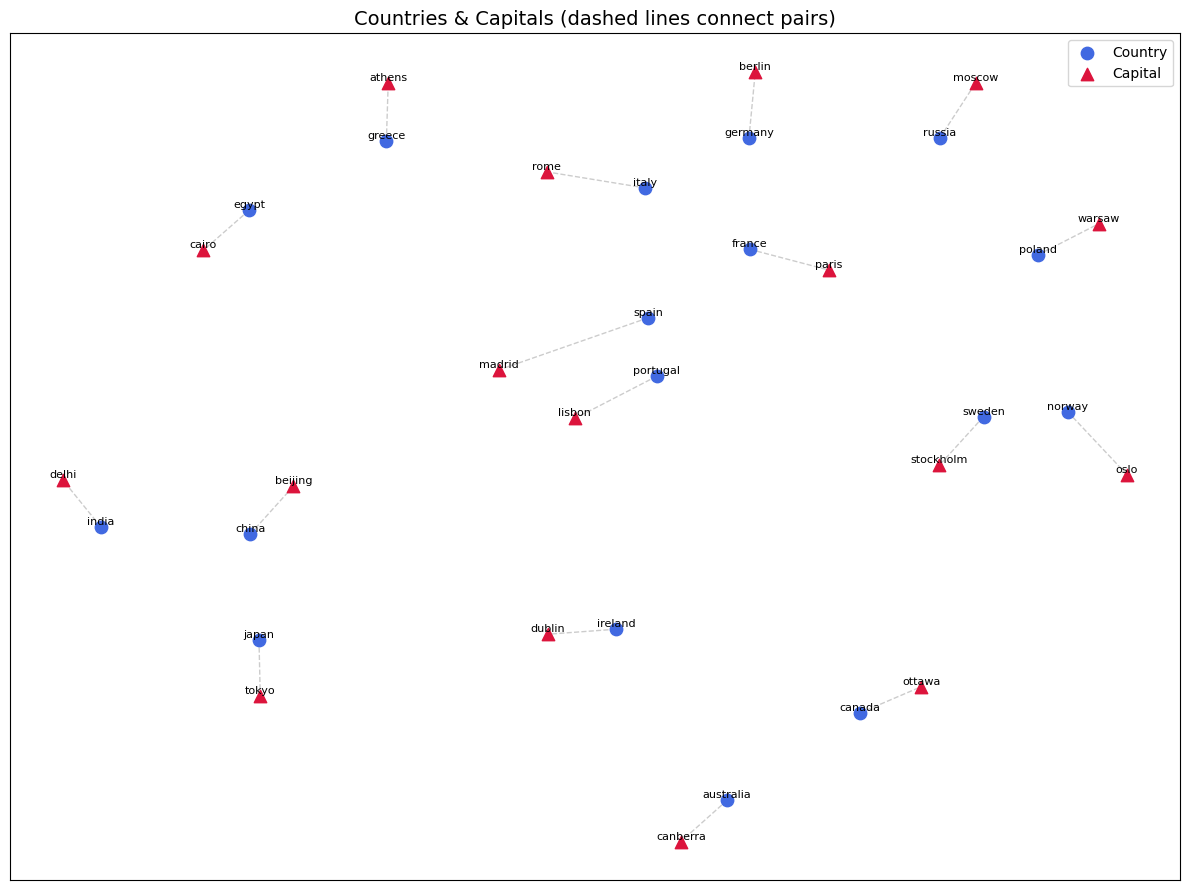

In [13]:
COUNTRY_CAPITAL = {
    "france": "paris", "germany": "berlin", "italy": "rome", "japan": "tokyo",
    "china": "beijing", "russia": "moscow", "spain": "madrid", "india": "delhi",
    "canada": "ottawa", "australia": "canberra", "sweden": "stockholm",
    "poland": "warsaw", "egypt": "cairo", "greece": "athens",
    "portugal": "lisbon", "ireland": "dublin", "norway": "oslo",
}

# Filter to pairs where both words are in vocabulary
geo_words, geo_vecs, geo_types = [], [], []
pairs_found = []
for country, capital in COUNTRY_CAPITAL.items():
    if country in vocab.word2id and capital in vocab.word2id:
        geo_words.extend([country, capital])
        geo_vecs.append(normalized[vocab.word2id[country]])
        geo_vecs.append(normalized[vocab.word2id[capital]])
        geo_types.extend(["Country", "Capital"])
        pairs_found.append((country, capital))

geo_vecs = np.array(geo_vecs)
tsne_geo = TSNE(n_components=2, perplexity=8, random_state=42, max_iter=2000)
coords_geo = tsne_geo.fit_transform(geo_vecs)

fig, ax = plt.subplots(figsize=(12, 9))
type_style = {"Country": ("royalblue", "o"), "Capital": ("crimson", "^")}

for i, (w, t) in enumerate(zip(geo_words, geo_types)):
    c, m = type_style[t]
    ax.scatter(coords_geo[i, 0], coords_geo[i, 1], c=c, marker=m, s=80, zorder=3)
    ax.annotate(w, (coords_geo[i, 0], coords_geo[i, 1]),
                 fontsize=8, ha="center", va="bottom")

# Draw lines between country-capital pairs
for country, capital in pairs_found:
    ci = geo_words.index(country)
    capi = geo_words.index(capital)
    ax.plot([coords_geo[ci, 0], coords_geo[capi, 0]],
            [coords_geo[ci, 1], coords_geo[capi, 1]],
            c="grey", alpha=0.4, linewidth=1, linestyle="--")

for label, (c, m) in type_style.items():
    ax.scatter([], [], c=c, marker=m, s=80, label=label)
ax.legend(fontsize=10)
ax.set_title("Countries & Capitals (dashed lines connect pairs)", fontsize=14)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()

## 4. Similarity Heatmap

Cosine similarity matrix for a curated set of words, with hierarchical clustering to reveal semantic blocks.

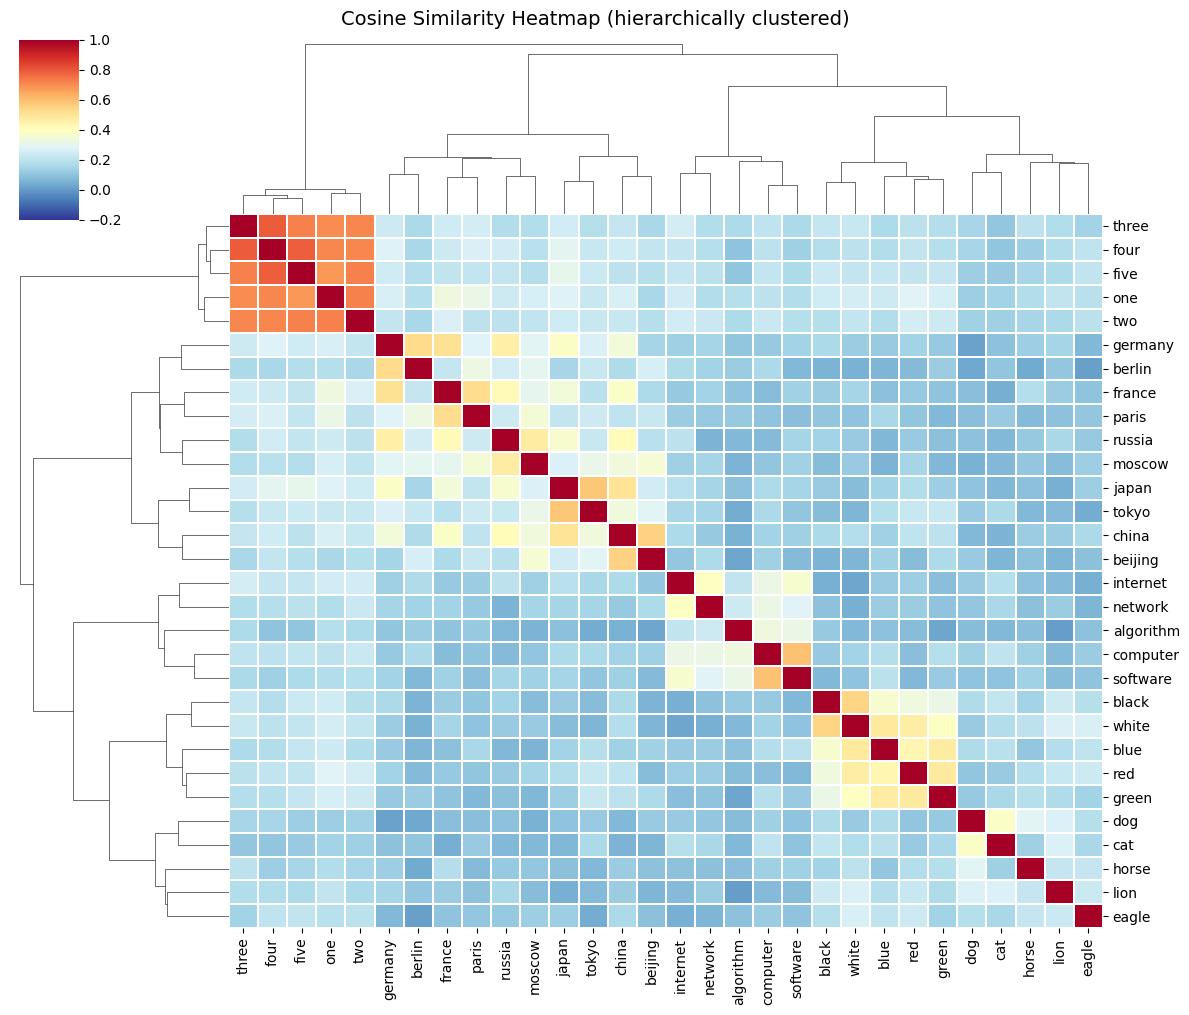

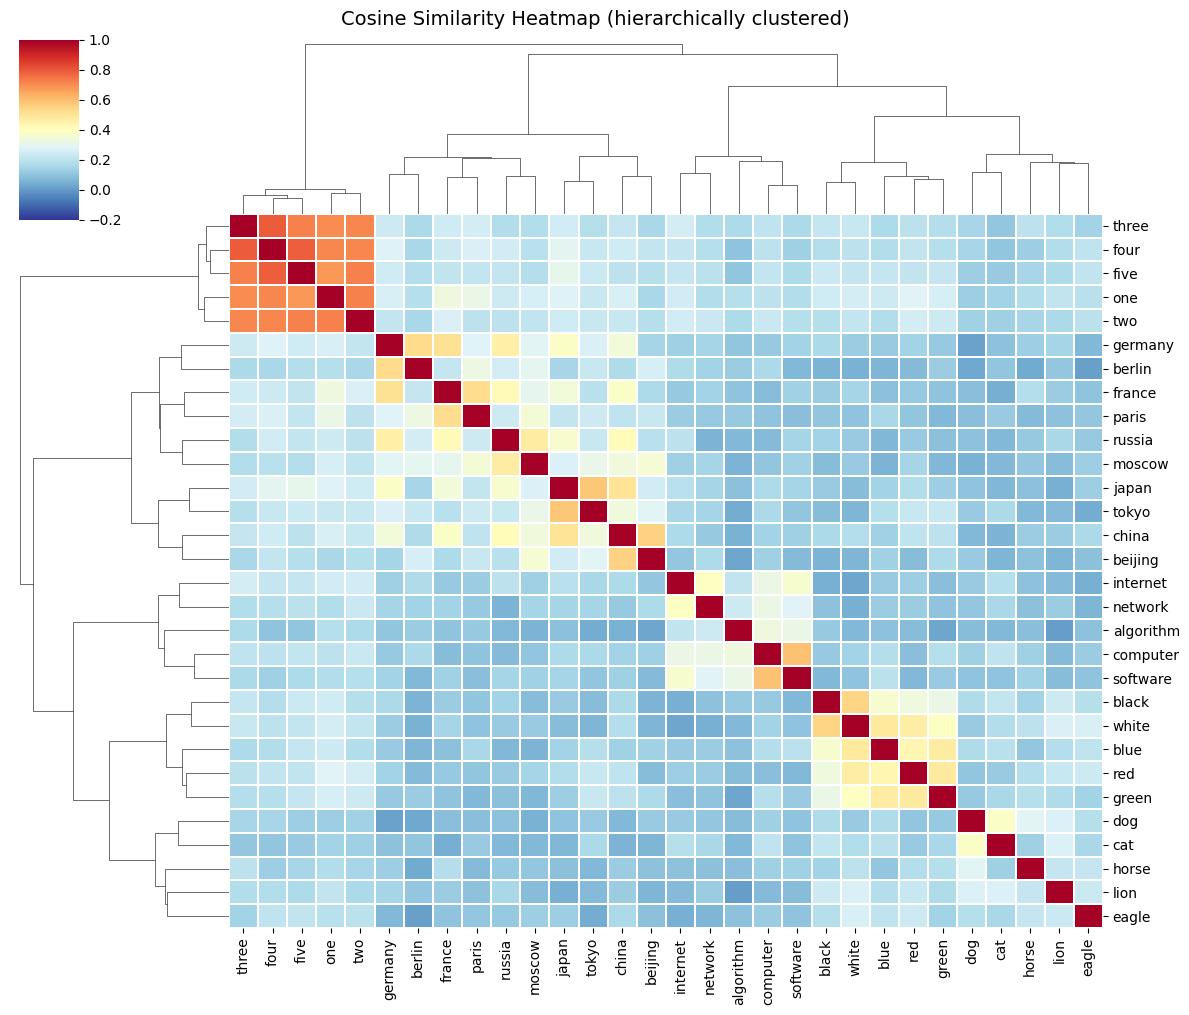

In [14]:
HEATMAP_WORDS = [
    # Countries
    "france", "germany", "japan", "china", "russia",
    # Capitals
    "paris", "berlin", "tokyo", "beijing", "moscow",
    # Numbers
    "one", "two", "three", "four", "five",
    # Animals
    "dog", "cat", "horse", "lion", "eagle",
    # Technology
    "computer", "software", "internet", "network", "algorithm",
    # Colors
    "red", "blue", "green", "black", "white",
]

# Filter and build similarity matrix
hw = [w for w in HEATMAP_WORDS if w in vocab.word2id]
hw_vecs = np.array([normalized[vocab.word2id[w]] for w in hw])
sim_matrix = hw_vecs @ hw_vecs.T

# Hierarchical clustering for reordering
link = linkage(1 - sim_matrix, method="ward")

fig, ax = plt.subplots(figsize=(12, 10))
g = sns.clustermap(
    sim_matrix,
    xticklabels=hw,
    yticklabels=hw,
    row_linkage=link,
    col_linkage=link,
    cmap="RdYlBu_r",
    vmin=-0.2,
    vmax=1.0,
    figsize=(12, 10),
    annot=False,
    linewidths=0.3,
)
g.fig.suptitle("Cosine Similarity Heatmap (hierarchically clustered)", y=1.01, fontsize=14)
plt.close(fig)  # close the unused empty figure
g.fig